<a href="https://colab.research.google.com/github/LeonimerMelo/Reinforcement-Learning/blob/On-Policy-Algorithm/SARSA_On_Policy_Algorithm_(RL)_v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#SARSA - On-Policy Algorithm

**SARSA** é o primeiro algoritmo baseado em valor abordado. Ele foi criado por **Rummery e Niranjan** em seu artigo de 1994, *“On-Line Q-Learning Using Connectionist Systems”*. O nome **SARSA** reflete o fato de que o algoritmo requer a sequência **Estado-Ação-Recompensa-Estado-Ação** para realizar uma atualização.

## **Algoritmos Baseados em Valor**
- Esses algoritmos avaliam pares estado-ação $(s, a)$ aprendendo uma das funções de valor:  
  - $ V^\pi(s) $: valor de um estado sob uma política $ \pi $.  
  - $ Q^\pi(s, a) $: valor de uma ação específica em um estado, sob a política $ \pi $.  

- O SARSA aprende $ Q^\pi(s, a) $, enquanto outros algoritmos, como o **Actor-Critic**, aprendem $ V^\pi(s) $.

## **Principais Ideias do SARSA**
O algoritmo é baseado em dois conceitos fundamentais:

### 1. **Aprendizado por Diferença Temporal (TD)**
- O aprendizado por diferença temporal é uma técnica usada para estimar valores de estado ou valores de pares estado-ação com base nas experiências que o agente coleta no ambiente.
- Essa técnica é uma alternativa ao **método Monte Carlo**, que também estima valores, mas **exige episódios completos**.

### 2. **Geração de Ações com Base na Função $ Q $**
- O algoritmo utiliza a função $ Q $ para decidir quais ações tomar.
- Isso levanta o problema do equilíbrio entre:
  - **Exploration:** aprender mais sobre o ambiente.
  - **Exploitation:** usar o que o agente já sabe para maximizar a recompensa.
- Esse dilema é conhecido como o **exploration-exploitation tradeoff**.
- Uma abordagem simples para resolver o problema é a **política ε-greedy**, que mistura exploration-exploitation com base em uma probabilidade $ ε $.

O **SARSA** (State-Action-Reward-State-Action) é um algoritmo de aprendizado por reforço **on-policy** utilizado para resolver problemas de controle, como encontrar uma política ótima em um ambiente de tomada de decisão. Ele é baseado no **Q-learning**, mas com uma diferença chave: o SARSA segue a política que está sendo avaliada e melhorada.

## **Como o SARSA Funciona**
O nome do algoritmo vem da sequência que ele utiliza para atualizar os valores de $ Q(s, a): (s_t, a_t, r_{t+1}, s_{t+1}, a_{t+1})$

Esses termos representam:
- $ s_t $: o estado atual.
- $ a_t $: a ação tomada no estado atual.
- $ r_{t+1} $: a recompensa recebida ao tomar a ação $ a_t $.
- $ s_{t+1} $: o próximo estado alcançado.
- $ a_{t+1} $: a próxima ação escolhida pela política no estado $ s_{t+1} $.

### **Atualização da Função Q**
O SARSA utiliza a seguinte fórmula para atualizar os valores de $ Q(s, a) $:
$$
Q(s_t, a_t) \gets Q(s_t, a_t) + \alpha \left[ r_{t+1} + \gamma Q(s_{t+1}, a_{t+1}) - Q(s_t, a_t) \right]
$$
Onde:
- $ \alpha $: taxa de aprendizado ($ 0 < \alpha \leq 1 $).
- $ \gamma $: fator de desconto ($ 0 \leq \gamma \leq 1 $).
- $ r_{t+1} + \gamma Q(s_{t+1}, a_{t+1}) $: **retorno esperado** para a próxima etapa da política.

Essa atualização é feita iterativamente para ajustar os valores $ Q(s, a) $ até convergir para uma política ótima.

---

### **Diferença entre SARSA e Q-Learning**
- **SARSA (On-policy):** A atualização de $ Q(s, a) $ usa a ação $ a_{t+1} $, que é selecionada pela **mesma política atual** que está sendo aprendida.
- **Q-Learning (Off-policy):** A atualização de $ Q(s, a) $ usa a ação que maximiza $ Q(s', a') $, independentemente da política atual.

**Exemplo prático:**
- Se a política atual for exploratória ($\epsilon$-greedy), o SARSA levará em conta essa exploração. Já o Q-Learning assume que a ação ótima será sempre tomada no próximo estado.

---

### **Fluxo do Algoritmo SARSA**

1. **Inicialização:**
   - Inicialize a tabela $ Q(s, a) $ com valores arbitrários (ex.: zeros).
   - Escolha o estado inicial $ s_0 $.

2. **Interação com o Ambiente:**
   - Para cada episódio:
     1. Escolha uma ação $ a_t $ com base na política atual (ex.: $\epsilon$-greedy).
     2. Execute a ação $ a_t $ e observe $ r_{t+1} $ (recompensa) e $ s_{t+1} $ (próximo estado).
     3. Escolha a próxima ação $ a_{t+1} $ usando a política atual.
     4. Atualize $ Q(s_t, a_t) $ usando a fórmula de atualização.
     5. Atualize $ s_t \gets s_{t+1} $ e $ a_t \gets a_{t+1} $.

3. **Repetição:**
   - Continue até convergir para uma política estável ou atingir o número máximo de episódios.

---

### **Pseudocódigo do SARSA**
```python
Inicializar Q(s, a) arbitrariamente
Para cada episódio:
    Inicializar s
    Escolher a a partir de s usando política derivada de Q (ex.: ε-greedy)
    Enquanto s não for terminal:
        Executar a, observar r e s'
        Escolher a' a partir de s' usando política derivada de Q (ex.: ε-greedy)
        Atualizar Q(s, a): Q(s, a) += α [r + γ Q(s', a') - Q(s, a)]
        s <- s'
        a <- a'
```

---

### **Exemplo Prático em Python**
Aqui está uma implementação básica do SARSA para resolver o problema do ambiente `CliffWalking-v0` do Gym:

In [2]:
pip install gymnasium -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 958.1/958.1 kB 11.3 MB/s eta 0:00:00


Política final (ações por estado): [1 1 1 1 1 1 1 1 1 1 2 2 0 1 1 1 1 1 1 1 1 1 1 2 0 0 1 0 1 3 0 1 3 0 1 2 0
 0 0 0 0 0 0 0 0 0 0 0]




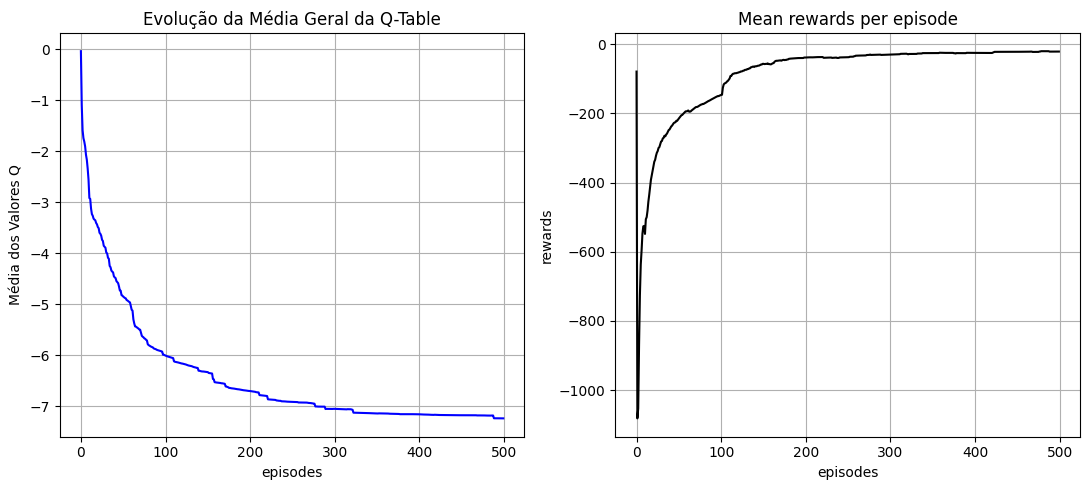

In [31]:
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt

def epsilon_greedy_policy(Q, state, n_actions, epsilon):
    if np.random.rand() < epsilon:
        return np.random.choice(n_actions)  # Exploration
    else:
        return np.argmax(Q[state])  # Exploitation baseada em Q

# anbiente de simulação
max_episode_steps_ = 500 # truncate afther this
env = gym.make('CliffWalking-v0', render_mode=None, max_episode_steps = max_episode_steps_)

# Parâmetros
num_episodes = 500
alpha = 0.1
gamma = 0.9
epsilon = 0.1
q_table_history = []
rewards_per_episode = []     # list to store rewards for each episode

Q = np.zeros((env.observation_space.n, env.action_space.n))  # Inicializa Q

# Treinamento
for episode in range(num_episodes):
    state, _ = env.reset()
    action = epsilon_greedy_policy(Q, state, env.action_space.n, epsilon)
    done = False
    rewards = 0
    while not done:
        next_state, reward, terminated, truncated, _ = env.step(action)
        next_action = epsilon_greedy_policy(Q, next_state, env.action_space.n, epsilon)

        # Atualiza Q usando a fórmula do SARSA
        Q[state, action] += alpha * (reward + gamma * Q[next_state, next_action] - Q[state, action])

        state = next_state
        action = next_action

        rewards += reward
        done =  terminated or truncated

    q_table_history.append(np.mean(Q))  # Armazenar média geral da Q-Table
    rewards_per_episode.append(rewards) # Store rewards per episode

env.close()

# Política aprendida
policy = np.argmax(Q, axis=1)
print("Política final (ações por estado):", policy)
print('\n')

# Graph mean rewards
mean_rewards_ = []
for t in range(num_episodes):
    # calculo a média móvel dos rewards de 100 episódios
    mean_rewards_.append(np.mean(rewards_per_episode[max(0, t-100):(t+1)]))

plt.figure(figsize = (11,5))
plt.subplot(1,2,1)
plt.plot(q_table_history, label="Média Geral da Q-Table", color="blue")
plt.title("Evolução da Média Geral da Q-Table")
plt.xlabel("episodes")
plt.ylabel("Média dos Valores Q")
plt.xticks()
plt.yticks()
plt.grid()
plt.subplot(1,2,2)
plt.title('Mean rewards per episode')
plt.xlabel('episodes')
plt.ylabel('rewards')
plt.plot(mean_rewards_, color="black")
plt.xticks()
plt.yticks()
plt.tight_layout()
plt.grid()
plt.show()

### Imprimindo a Q-Table
Cada linha da tabela representa um estado, e cada valor na linha representa o valor $ Q(s, a) $ associado às ações disponíveis no estado.

In [32]:
# Imprimindo a Q-Table após o treinamento
print("Q-Table após o treinamento:")
# o ambiente tem 48 estados (CliffWalking-v0)
for state in range(env.observation_space.n):
    print(f"Estado {state}: {Q[state]}")

Q-Table após o treinamento:
Estado 0: [-7.83512652 -7.78177582 -7.79450982 -7.84374544]
Estado 1: [-7.62511725 -7.532563   -7.5747805  -7.71964777]
Estado 2: [-7.26931716 -7.26435067 -7.27206509 -7.43749905]
Estado 3: [-7.00713048 -6.96774105 -6.98422292 -7.095175  ]
Estado 4: [-6.63541567 -6.59430767 -6.62553898 -6.93196654]
Estado 5: [-6.30975269 -6.2097268  -6.30094194 -6.39552434]
Estado 6: [-5.90717576 -5.7871349  -5.91464793 -6.1400259 ]
Estado 7: [-5.38706457 -5.32712104 -5.32924504 -5.66403943]
Estado 8: [-4.90973825 -4.82332796 -4.83345798 -4.9972412 ]
Estado 9: [-4.37615741 -4.25111152 -4.26725417 -4.53089147]
Estado 10: [-3.70628059 -3.65123937 -3.64957163 -3.96316132]
Estado 11: [-3.12011433 -3.22048281 -3.01873469 -3.3807735 ]
Estado 12: [-7.99965001 -8.14152364 -8.03200184 -8.00784867]
Estado 13: [ -7.6037849   -7.39520946 -11.66755124  -7.67440661]
Estado 14: [ -7.16821626  -7.06425317 -10.33536839  -7.2488649 ]
Estado 15: [-6.82767443 -6.72420137 -7.27370006 -6.77753336

In [33]:
import pandas as pd

# Convertendo a Q-Table para um DataFrame para visualização mais clara
acao=['UP', 'RIGHT', 'DOWN', 'LEFT']
q_table_df = pd.DataFrame(Q, columns=[f"{acao[i]}" for i in range(env.action_space.n)])
print("Q-Table formatada:")
print(q_table_df)

Q-Table formatada:
          UP       RIGHT       DOWN       LEFT
0  -7.835127   -7.781776  -7.794510  -7.843745
1  -7.625117   -7.532563  -7.574781  -7.719648
2  -7.269317   -7.264351  -7.272065  -7.437499
3  -7.007130   -6.967741  -6.984223  -7.095175
4  -6.635416   -6.594308  -6.625539  -6.931967
5  -6.309753   -6.209727  -6.300942  -6.395524
6  -5.907176   -5.787135  -5.914648  -6.140026
7  -5.387065   -5.327121  -5.329245  -5.664039
8  -4.909738   -4.823328  -4.833458  -4.997241
9  -4.376157   -4.251112  -4.267254  -4.530891
10 -3.706281   -3.651239  -3.649572  -3.963161
11 -3.120114   -3.220483  -3.018735  -3.380773
12 -7.999650   -8.141524  -8.032002  -8.007849
13 -7.603785   -7.395209 -11.667551  -7.674407
14 -7.168216   -7.064253 -10.335368  -7.248865
15 -6.827674   -6.724201  -7.273700  -6.777533
16 -6.454497   -6.376082  -7.269118  -6.438922
17 -6.066715   -5.969579  -6.512605  -6.189589
18 -5.699460   -5.475099  -6.690948  -5.916324
19 -5.104711   -4.989123  -8.116805  -5.3

Se quisermos exibir os valores ótimos da **Q-Table** no formato de um grid **4x12** (como no ambiente **CliffWalking-v0**), podemos mapear os valores ótimos $ \max(Q(s, a)) $ de cada estado para suas respectivas posições no grid.

Aqui está o código para imprimir o **4x12 grid** com os valores ótimos da Q-Table:

In [52]:
# Função para imprimir o grid 4x12 com os índices das ações no grid 4x12
def print_optimal_values(q_table, rows, cols):
    optimal_values = np.argmax(q_table, axis=1)  # Seleciona o índice ótimo (argmax Q) para cada estado
    grid = optimal_values.reshape((rows, cols))  # Reshape para o formato do grid (4x12)

    print("índices de ações ótimas (argmax Q) no formato 4x12 grid:")
    for row in grid:
        print('-------------------------------------------------')
        print('|', " | ".join(f"{value:d}" for value in row), '|')
    print('-------------------------------------------------')

print('0: Move up')
print('1: Move right')
print('2: Move down')
print('3: Move left\n')

# Imprimir o grid com valores ótimos
print_optimal_values(Q, rows=4, cols=12)

0: Move up
1: Move right
2: Move down
3: Move left

índices de ações ótimas (argmax Q) no formato 4x12 grid:
-------------------------------------------------
| 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 2 | 2 |
-------------------------------------------------
| 0 | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 2 |
-------------------------------------------------
| 0 | 0 | 1 | 0 | 1 | 3 | 0 | 1 | 3 | 0 | 1 | 2 |
-------------------------------------------------
| 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 |
-------------------------------------------------


#### Explicação do Código
1. **Seleção dos Valores Ótimos**:
   - Usamos `np.argmax(q_table, axis=1)` para selecionar o índice de maior valor de $ Q(s, a) $ para cada estado $ s $.
   
2. **Formatação em Grid**:
   - Usamos `.reshape((rows, cols))` para reorganizar os valores em um formato 4x12.

3. **Impressão do Grid**:
   - Cada linha é formatada para mostrar os valores do índices das ações.

### Adicionando Direções das Ações
Para se exibir as ações ótimas (política aprendida) em vez dos valores $ Q $, substitua por `np.argmax` para obter a ação ótima de cada estado.


In [54]:
def print_optimal_policy(q_table, rows, cols, actions=["↑", "→", "↓", "←", "G", "S", "C"]):
    optimal_actions = np.argmax(q_table, axis=1)  # Seleciona as ações ótimas
    grid = optimal_actions.reshape((rows, cols))
    for i in range(cols):
      grid[rows-1,i]=6
    grid[rows-1,cols-1]=4
    grid[rows-1,0]=5

    print("Política ótima no formato 4x12 grid:")
    for row in grid:
        print('-------------------------------------------------')
        print('|', " | ".join(f"{actions[action]}" for action in row), '|')
    print('-------------------------------------------------')

# Exibir a política ótima
print_optimal_policy(Q, rows=4, cols=12)

Política ótima no formato 4x12 grid:
-------------------------------------------------
| → | → | → | → | → | → | → | → | → | → | ↓ | ↓ |
-------------------------------------------------
| ↑ | → | → | → | → | → | → | → | → | → | → | ↓ |
-------------------------------------------------
| ↑ | ↑ | → | ↑ | → | ← | ↑ | → | ← | ↑ | → | ↓ |
-------------------------------------------------
| S | C | C | C | C | C | C | C | C | C | C | G |
-------------------------------------------------


- Cada símbolo representa a ação ótima para o estado $( ↑, →, ↓, ← )$.
- O "G" representa a meta no ambiente, o "S" o start e o "C" o `cliff`

### **Vantagens do SARSA**
1. **Aprendizado seguro:** Como considera a política atual, SARSA tende a ser mais seguro e evita explorar áreas perigosas (ex.: no CliffWalking).
2. **Exploração consistente:** Reflete a natureza exploratória da política ($\epsilon$-greedy).

### **Desvantagens**
1. Pode levar mais tempo para convergir, pois depende da política exploratória.
2. Geralmente, o desempenho é inferior ao do Q-Learning em ambientes onde ações exploratórias não são tão relevantes.